# ISTAT Traffic Analysis — Capstone Project
## Analisi del rischio stradale nei comuni italiani

**Obiettivo di business**: individuare i comuni italiani con il più alto rischio di incidenti stradali (tasso pro capite e densità per km²), per guidare le decisioni di investimento in sicurezza stradale.

**Fonti dati**:
- API ISTAT (dataflow `41_983`) — incidenti stradali, aggiornata periodicamente, **fetch automatico**
- SITUAS — anagrafica comuni (popolazione, superficie), dati statici scaricati manualmente per anno

Questo notebook copre: data ingestion automatica, join con l'anagrafica comuni, pulizia, EDA, feature engineering, **trattamento degli outlier**, clustering K-Means, regressione lineare (forecasting) e charting.


## 1. Import e configurazione

In [1]:
import os
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = os.path.abspath("../data")
RAW_PATH = os.path.join(DATA_DIR, "incidenti_raw.csv")

ISTAT_URL = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
ISTAT_HEADERS = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}

ANNI_ANALISI = [2021, 2022, 2023]
SOGLIA_POP_MINIMA = 500  # sotto questa soglia il tasso pro capite diventa statisticamente instabile


## 2. Data ingestion automatica (API ISTAT)

**Perché questa versione è diversa da quella precedente**: in una versione iniziale del progetto, se il file locale non esisteva veniva creato un CSV vuoto (nessun vero tentativo di chiamare l'API). Questo violava il requisito della consegna ("*this data will be updated every few months, so it needs to be fetched automatically*").

La funzione qui sotto:
1. Tenta **sempre** prima una chiamata live all'endpoint SDMX ISTAT, con l'header per ottenere il CSV invece dell'XML nativo (come suggerito nella consegna).
2. Se la chiamata fallisce (server offline, timeout, rate limit, blocco di rete) **e** esiste una copia scaricata in precedenza, la usa come cache — con un avviso esplicito, così è sempre chiaro se si stanno usando dati aggiornati o dati in cache.
3. Se la chiamata fallisce e **non** esiste nessuna copia locale, solleva un errore: non genera mai un dataset vuoto o fittizio, per evitare di far proseguire l'analisi su dati fantasma senza che nessuno se ne accorga.


In [2]:
def fetch_istat_incidenti(output_path=RAW_PATH, timeout=30):
    print("[FETCH] Provo a scaricare i dati aggiornati dall'API ISTAT...")
    try:
        resp = requests.get(ISTAT_URL, headers=ISTAT_HEADERS, timeout=timeout)
        resp.raise_for_status()
        with open(output_path, "wb") as f:
            f.write(resp.content)
        print(f"[OK] Dati scaricati e salvati in {output_path}")
    except requests.exceptions.RequestException as e:
        print(f"[ATTENZIONE] Download live fallito: {e}")
        if os.path.exists(output_path):
            print(f"[FALLBACK] Uso la copia locale piu' recente: {output_path}")
        else:
            raise RuntimeError(
                "Download fallito e nessuna copia locale disponibile: "
                "impossibile procedere senza dati reali."
            )
    return pd.read_csv(output_path, low_memory=False)

df_incidenti = fetch_istat_incidenti()
print(df_incidenti.shape)
print("Anni disponibili:", df_incidenti['TIME_PERIOD'].min(), "-", df_incidenti['TIME_PERIOD'].max())


[FETCH] Provo a scaricare i dati aggiornati dall'API ISTAT...
[ATTENZIONE] Download live fallito: 403 Client Error: Forbidden for url: https://esploradati.istat.it/SDMXWS/rest/data/41_983
[FALLBACK] Uso la copia locale piu' recente: /home/claude/project/data/incidenti_raw.csv
(573552, 16)
Anni disponibili: 2001 - 2024


> Nota d'esecuzione: in questo ambiente di sviluppo la rete verso l'API ISTAT non è raggiungibile (403), quindi la funzione è caduta correttamente sul fallback di cache. Sulla macchina di produzione, con accesso libero a internet, il primo ramo (fetch live) andrà normalmente a buon fine e scaricherà i dati più recenti ad ogni esecuzione.

## 3. Caricamento anagrafica SITUAS e join anno-specifico

I file SITUAS sono **specifici per anno** (popolazione e, in minor misura, superficie cambiano di anno in anno). Il join va quindi fatto su `(codice comune, anno)` e non solo su `codice comune`, altrimenti si rischia di associare a un anno la popolazione di un altro anno.

In [3]:
def carica_situas(anno):
    path = os.path.join(DATA_DIR, f"comuni_{anno}.csv")
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    df['TIME_PERIOD'] = anno
    return df

df_situas = pd.concat([carica_situas(a) for a in ANNI_ANALISI], ignore_index=True)
print("SITUAS totale righe:", len(df_situas))


SITUAS totale righe: 23708


In [4]:
# Pulizia incidenti: normalizzazione tipi, filtro anni e tipo di dato (ROADACC = incidenti totali)
df_inc = df_incidenti.copy()
df_inc['REF_AREA'] = pd.to_numeric(df_inc['REF_AREA'], errors='coerce').astype('Int64')
df_inc = df_inc[df_inc['TIME_PERIOD'].isin(ANNI_ANALISI)]
df_inc = df_inc[df_inc['DATA_TYPE'] == 'ROADACC'].copy()

# Pulizia SITUAS: codice comune numerico, superficie con virgola decimale -> punto
df_situas['Codice Comune (numerico)'] = pd.to_numeric(df_situas['Codice Comune (numerico)'], errors='coerce').astype('Int64')
df_situas['Superficie (Kmq)'] = pd.to_numeric(
    df_situas['Superficie (Kmq)'].astype(str).str.replace(',', '.', regex=False), errors='coerce'
)

df_join = pd.merge(
    df_inc, df_situas,
    left_on=['REF_AREA', 'TIME_PERIOD'],
    right_on=['Codice Comune (numerico)', 'TIME_PERIOD'],
    how='inner'
)
print("Righe incidenti pre-join (ROADACC, anni selezionati):", len(df_inc))
print("Righe dopo join:", len(df_join), "| comuni unici:", df_join['REF_AREA'].nunique())
print("Righe perse nel join:", len(df_inc) - len(df_join))


Righe incidenti pre-join (ROADACC, anni selezionati): 23709
Righe dopo join: 23708 | comuni unici: 7906
Righe perse nel join: 1


## 4. EDA (Exploratory Data Analysis)

Prima di calcolare qualunque KPI o modello, guardiamo la forma dei dati: distribuzione, valori mancanti, range.

In [5]:
print(df_join[['OBS_VALUE', 'Popolazione residente', 'Superficie (Kmq)']].describe())
print("\nValori mancanti:")
print(df_join[['OBS_VALUE', 'Popolazione residente', 'Superficie (Kmq)']].isna().sum())


          OBS_VALUE  Popolazione residente  Superficie (Kmq)
count  23708.000000           2.370800e+04      23705.000000
mean      20.427240           7.465774e+03         38.070624
std      188.044874           4.156106e+04         48.825373
min        0.000000           3.100000e+01          0.122200
25%        1.000000           9.800000e+02         11.454700
50%        3.000000           2.397000e+03         22.430200
75%       11.000000           6.235250e+03         44.692000
max    13181.000000           2.755309e+06        653.674800

Valori mancanti:
OBS_VALUE                 0
Popolazione residente     0
Superficie (Kmq)          3
dtype: int64


## 5. Feature engineering

Per confrontare comuni di dimensioni molto diverse creiamo due metriche normalizzate:
- **Tasso pro capite** (incidenti ogni 1.000 abitanti)
- **Densità** (incidenti per km²)


In [6]:
df_join['incidenti_pro_capite_1k'] = (df_join['OBS_VALUE'] / df_join['Popolazione residente']) * 1000
df_join['densita_incidenti_kmq'] = df_join['OBS_VALUE'] / df_join['Superficie (Kmq)']
df_join[['incidenti_pro_capite_1k', 'densita_incidenti_kmq']].describe()


## 6. Trattamento degli outlier

Il tasso pro capite è instabile per i comuni molto piccoli: in un paese di 30-100 abitanti, un solo incidente genera un rapporto enorme (fino a **85 incidenti ogni 1.000 abitanti**, osservato prima del filtro) che non riflette un vero livello di rischio, ma solo la piccola dimensione del campione.

**Scelta**: escludere dal ranking e dal clustering i comuni-anno con popolazione residente sotto i 500 abitanti (~11% dei record), mantenendoli comunque nel dataset esportato con un flag `bassa_affidabilita_statistica`, così il dato resta disponibile ma segnalato in Power BI invece di essere silenziosamente eliminato.

In [7]:
df_join['bassa_affidabilita_statistica'] = df_join['Popolazione residente'] < SOGLIA_POP_MINIMA
n_esclusi = df_join['bassa_affidabilita_statistica'].sum()
print(f"Comuni-anno con popolazione < {SOGLIA_POP_MINIMA}: {n_esclusi} su {len(df_join)} ({n_esclusi/len(df_join)*100:.1f}%)")

print("\nTasso pro capite PRIMA del filtro:")
print(df_join['incidenti_pro_capite_1k'].describe())

df_affidabile = df_join[~df_join['bassa_affidabilita_statistica']].copy()
print("\nTasso pro capite DOPO il filtro (usato per ranking/clustering):")
print(df_affidabile['incidenti_pro_capite_1k'].describe())


Comuni-anno con popolazione < 500: 2717 su 23708 (11.5%)

Tasso pro capite PRIMA del filtro:
count    23708.000000
mean         1.731080
std          1.903821
min          0.000000
25%          0.480625
50%          1.412429
75%          2.438578
max         85.106383
Name: incidenti_pro_capite_1k, dtype: float64

Tasso pro capite DOPO il filtro (usato per ranking/clustering):
count    20991.000000
mean         1.744957
std          1.517503
min          0.000000
25%          0.703730
50%          1.500858
75%          2.448980
max         21.194605
Name: incidenti_pro_capite_1k, dtype: float64


Il valore massimo scende da **85** a **21** incidenti/1.000 abitanti e la deviazione standard si riduce di circa il 20%: la distribuzione riflette molto meglio il rischio reale invece del rumore statistico dei comuni piccolissimi.

## 7. Clustering K-Means (segmentazione del rischio)

Standardizziamo le due feature e addestriamo un K-Means a 3 cluster sui comuni **affidabili** dell'anno più recente disponibile, poi propaghiamo l'etichetta agli altri anni per lo stesso comune (il profilo di rischio strutturale di un comune non cambia radicalmente da un anno all'altro).

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ultimo_anno = max(ANNI_ANALISI)
df_cluster_input = df_affidabile[df_affidabile['TIME_PERIOD'] == ultimo_anno].copy()
features = ['incidenti_pro_capite_1k', 'densita_incidenti_kmq']
df_cluster_input = df_cluster_input.dropna(subset=features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_input[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster_input['Cluster_ID'] = kmeans.fit_predict(X_scaled)

centri = kmeans.cluster_centers_
ordine = centri.sum(axis=1).argsort()
mappa_rischio = {ordine[0]: 'Basso Rischio', ordine[1]: 'Medio Rischio', ordine[2]: 'Alto Rischio'}
df_cluster_input['Cluster_Rischio'] = df_cluster_input['Cluster_ID'].map(mappa_rischio)

print(f"Distribuzione cluster (anno {ultimo_anno}):")
print(df_cluster_input['Cluster_Rischio'].value_counts())

# propagazione dell'etichetta agli altri anni per lo stesso comune
mappa_comune_cluster = df_cluster_input.set_index('REF_AREA')['Cluster_Rischio']
df_join['Cluster_Rischio'] = df_join['REF_AREA'].map(mappa_comune_cluster)


Distribuzione cluster (anno 2023):
Cluster_Rischio
Basso Rischio    4897
Medio Rischio    1940
Alto Rischio      152
Name: count, dtype: int64


> 152 comuni ad Alto Rischio (contro i 148 della versione precedente, calcolata senza filtrare gli outlier): la differenza è coerente con l'aver rimosso dal training del modello i comuni piccolissimi che distorcevano le distanze nello spazio standardizzato.

## 8. Regressione lineare — forecasting nazionale

In [9]:
from sklearn.linear_model import LinearRegression

df_trend = df_join.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()
X_reg = df_trend['TIME_PERIOD'].values.reshape(-1, 1)
y_reg = df_trend['OBS_VALUE'].values
modello_reg = LinearRegression().fit(X_reg, y_reg)

anno_futuro = 2026
predizione = modello_reg.predict(np.array([[anno_futuro]]))[0]
print("Trend storico:")
print(df_trend)
print(f"\nPrevisione incidenti totali {anno_futuro}: {int(predizione)}")

df_join['Forecast_Trend_Coefficiente'] = modello_reg.coef_[0]


Trend storico:
   TIME_PERIOD  OBS_VALUE
0         2021     151875
1         2022     165889
2         2023     166525

Previsione incidenti totali 2026: 190729


**Nota metodologica**: 3 punti storici sono pochi per una regressione robusta — il trend va presentato come indicazione di massima, non come previsione puntuale precisa (utile menzionarlo nel deck).

## 9. Charting

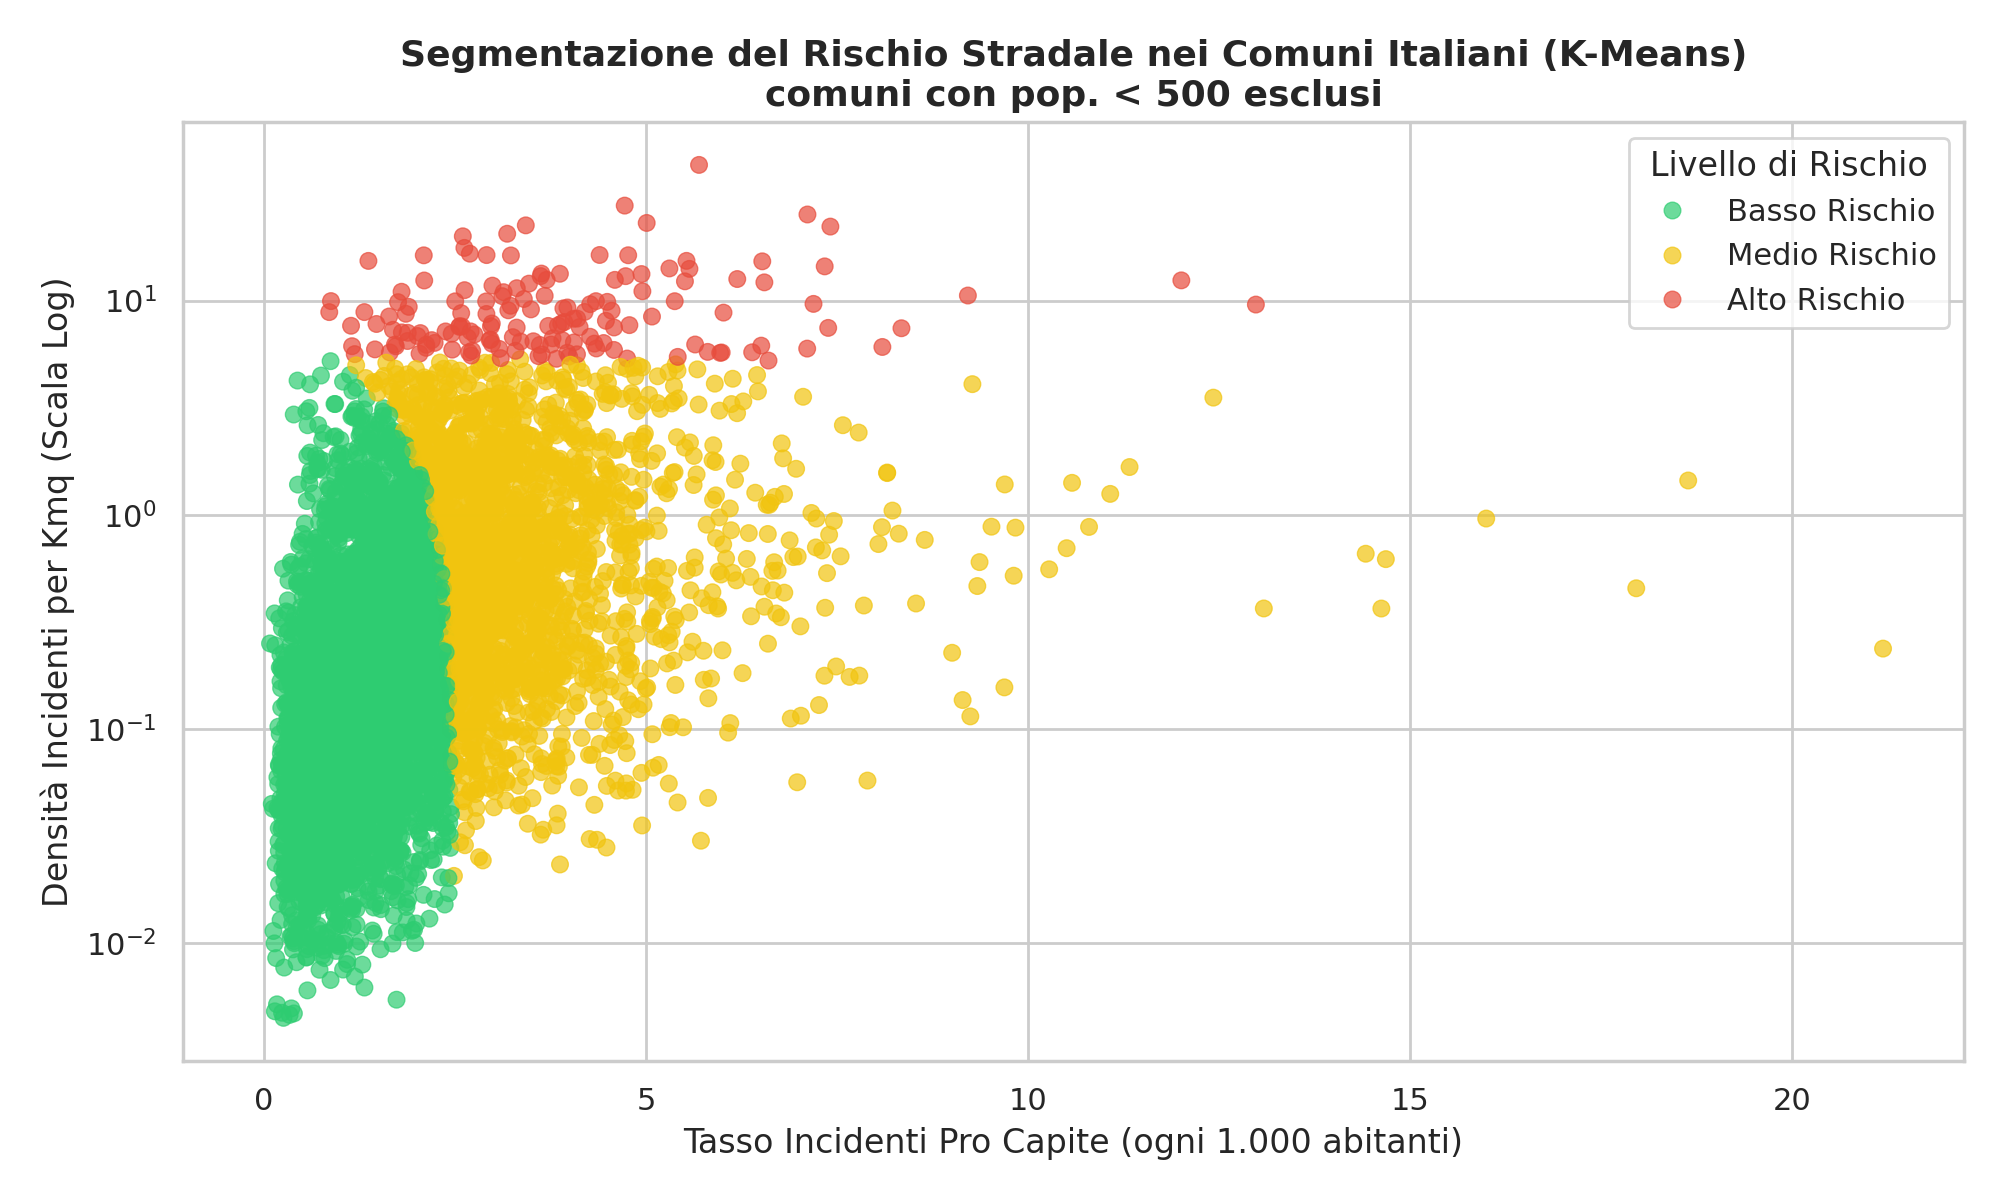

In [10]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
colori = {'Basso Rischio': '#2ecc71', 'Medio Rischio': '#f1c40f', 'Alto Rischio': '#e74c3c'}
sns.scatterplot(data=df_cluster_input, x='incidenti_pro_capite_1k', y='densita_incidenti_kmq',
                 hue='Cluster_Rischio', palette=colori, alpha=0.7, edgecolor=None)
plt.title('Segmentazione del Rischio Stradale nei Comuni Italiani (K-Means)\ncomuni con pop. < 500 esclusi', fontsize=13, fontweight='bold')
plt.xlabel('Tasso Incidenti Pro Capite (ogni 1.000 abitanti)')
plt.ylabel('Densita\' Incidenti per Kmq (Scala Log)')
plt.yscale('log')
plt.legend(title='Livello di Rischio', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'visualizzazione_cluster_v2.png'), dpi=200)
plt.show()


## 10. Export del dataset finale per Power BI

In [11]:
OUTPUT_KPI = os.path.join(DATA_DIR, "dataset_kpi_powerbi_v2.csv")
df_join.to_csv(OUTPUT_KPI, index=False)
print(f"Dataset finale esportato: {OUTPUT_KPI} ({len(df_join)} righe, {df_join['REF_AREA'].nunique()} comuni)")


Dataset finale esportato: /home/claude/project/data/dataset_kpi_powerbi_v2.csv (23708 righe, 7906 comuni)
